# Trabajo práctico 4: Aprendizaje No Supervisado

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys 
sys.path.append(os.path.abspath("./src"))
sys.path.append(os.path.abspath("./data"))

import utils as utls 
import pca as pca
import autoencoder as ae
import clustering as clust
from collections import Counter

## 1. Inspección de Datos

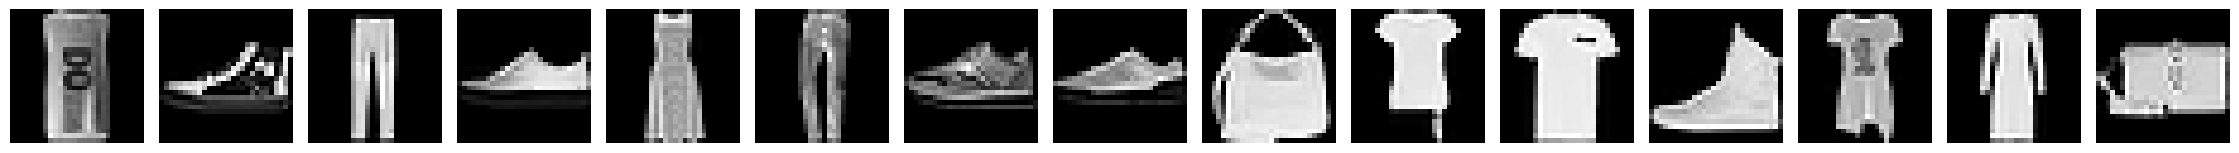

In [2]:
df = pd.read_csv("./data/fashion_mnist_subset.csv")

utls.plot_images(df, 15)
#Ver de hacer las fotos mas grandes


In [3]:
print(df.shape)
print(df.head())

# Separar features y etiquetas
# Asumiendo que la última columna es la etiqueta
X = df.iloc[:, :-1].values  # píxeles
y = df.iloc[:, -1].values   # etiquetas

(25000, 785)
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      0.0      0.0      0.0      0.0   0.0039   0.0000   
1      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
2      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   
3      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0627   
4      0.0      0.0      0.0      0.0      0.0      0.0   0.0000   0.0000   

   pixel_8  pixel_9  ...  pixel_775  pixel_776  pixel_777  pixel_778  \
0   0.0196   0.0902  ...     0.1647     0.0000     0.0000     0.0000   
1   0.0000   0.0000  ...     0.0000     0.0000     0.0000     0.0000   
2   0.0000   0.0000  ...     0.4235     0.2157     0.0000     0.0000   
3   0.2078   0.0000  ...     0.0549     0.0000     0.1529     0.3843   
4   0.0000   0.0000  ...     0.0000     0.0000     0.0078     0.0000   

   pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  label  
0     0.0000        0.0  

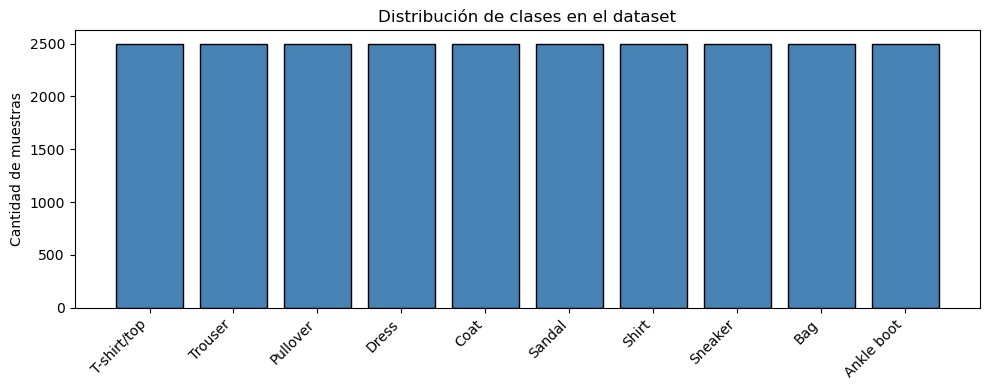

In [4]:
class_names = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

class_counts = Counter(y)
classes, counts = zip(*sorted(class_counts.items()))
labels = [class_names[c] for c in classes]

utls.barplot(labels, counts)

El dataset esta completamente balanceado, todas las clases tienen 2500 muestras. Esto significa que no hay riesgo de sesgos en el entrenamiento hacia ninguna clase en particular.

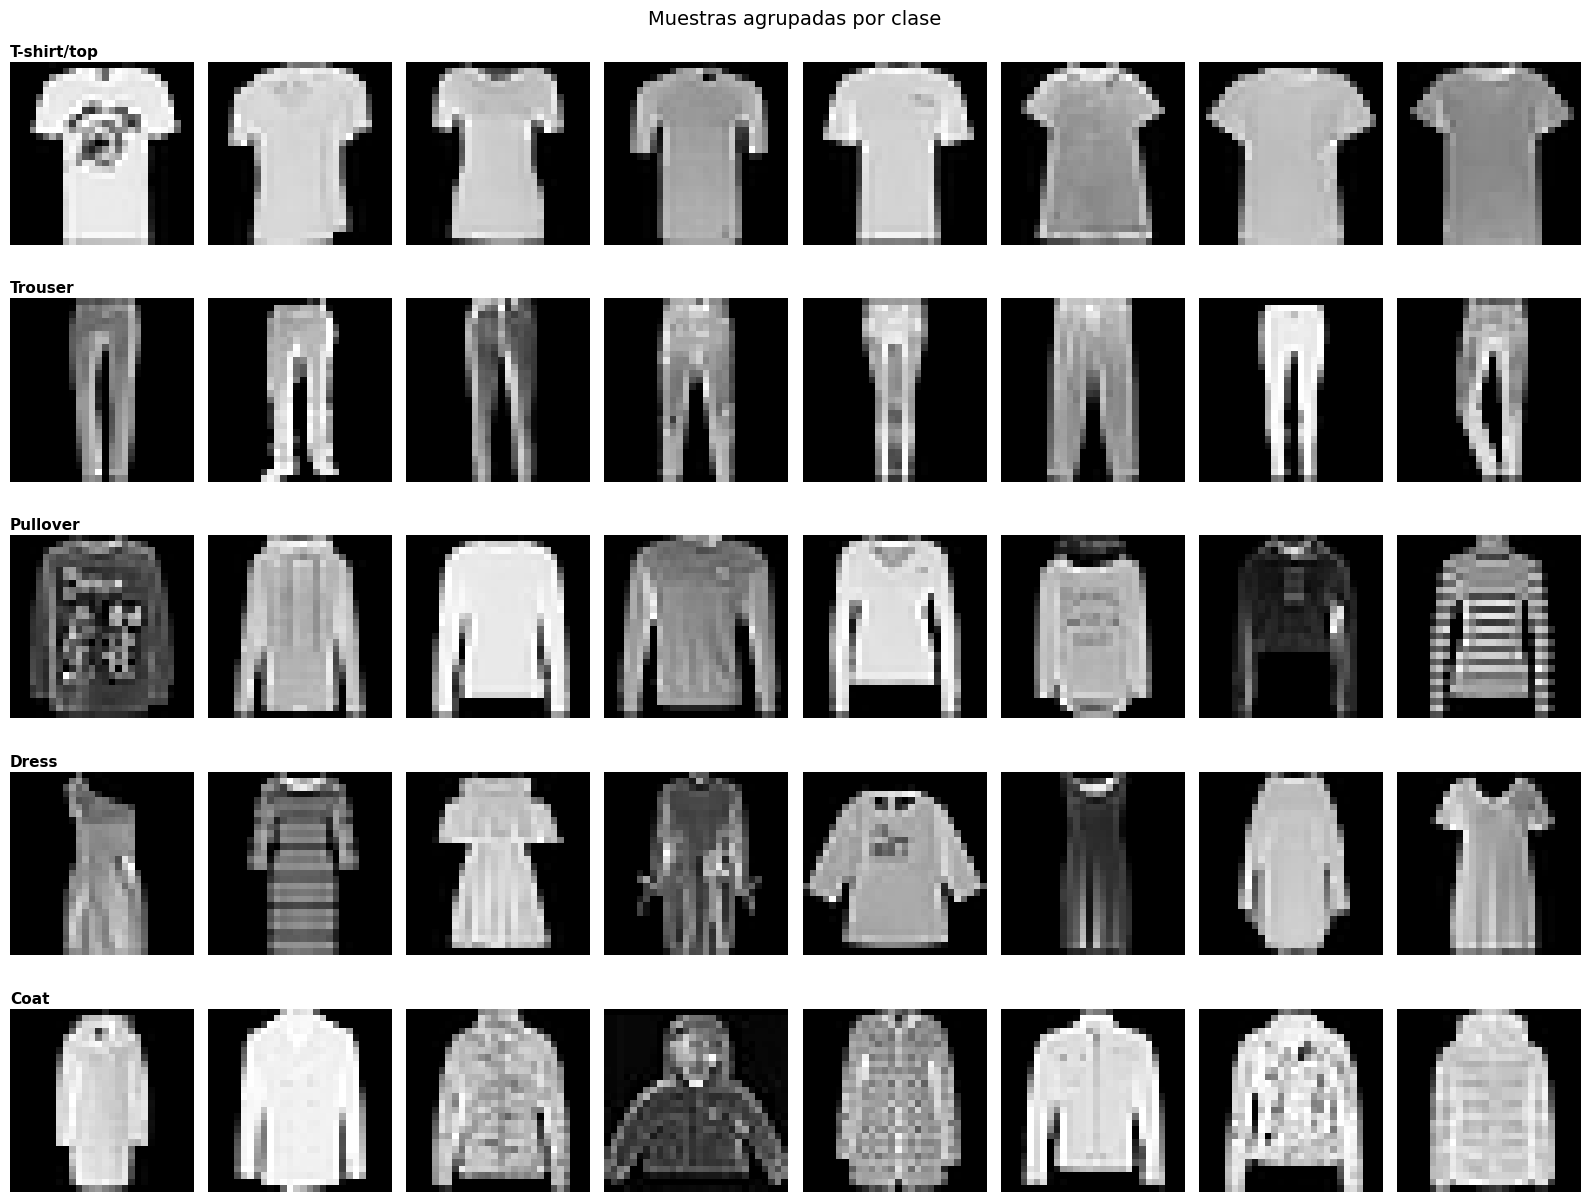

In [5]:
# Llamar la función con 5 clases y 8 muestras por clase
utls.plot_samples_by_class(X, y, class_names, n_samples=8,
                      classes_to_show=[0, 1, 2, 3, 4])

Se puede ver que dentro de las clases propias, la muestras varian mucho entre ellas, ya sea en color, estampado, largo o textura.

Tambien algunas clases pueden confundirse entre si por similitudes en los disenos, como vestidos, tapados y pullovers. Esto significa que los modelos de aprendizaje no supervisado podrian llegar a confundir estas clases.


### Split de Train/Test

In [6]:
# Split estratificado: cada subconjunto debe mantener la misma proporcion de clases que el dataset original

X_train, X_test, y_train, y_test = utls.stratified_split(X, y, test_size=0.2)



## 2. Reduccion de Dimensionalidad

In [7]:
# Estandarizar
X_train_std, X_test_std, med, des = utls.standarization(X_train, X_test)

In [8]:

# Aprender PCA sobre train para ver varianza
eigenvalues, eigenvectors = pca.pca_fit(X_train_std)

varianza_explicada = eigenvalues / np.sum(eigenvalues)
varianza_acumulada = np.cumsum(varianza_explicada)

# Elegir K componentes que expliquen el 90%
K = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes para 90% de varianza: {K}")

# Transformar train y test con K componentes
eigenvectors_K = eigenvectors[:, :K]  
X_train_pca = pca.pca_transform(X_train_std, eigenvectors_K)
X_test_pca  = pca.pca_transform(X_test_std,  eigenvectors_K)


Componentes para 90% de varianza: 135


Text(0, 0.5, 'Varianza explicada acumulada')

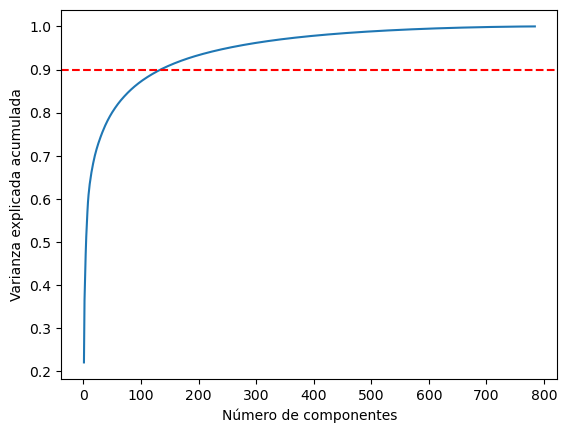

In [9]:
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada)
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')

Gracias a la reduccion de PCA, se puede identificar que 135 componentes son suficientes para capturar el 90% de la varianza de los datos, y por ende se puede descartar el 10% restante. Esto es porque al realizar la reconstruccion de los datos con estas 135 componentes de mayor varianza, se conserva el 90% de la informacion del dataset. 

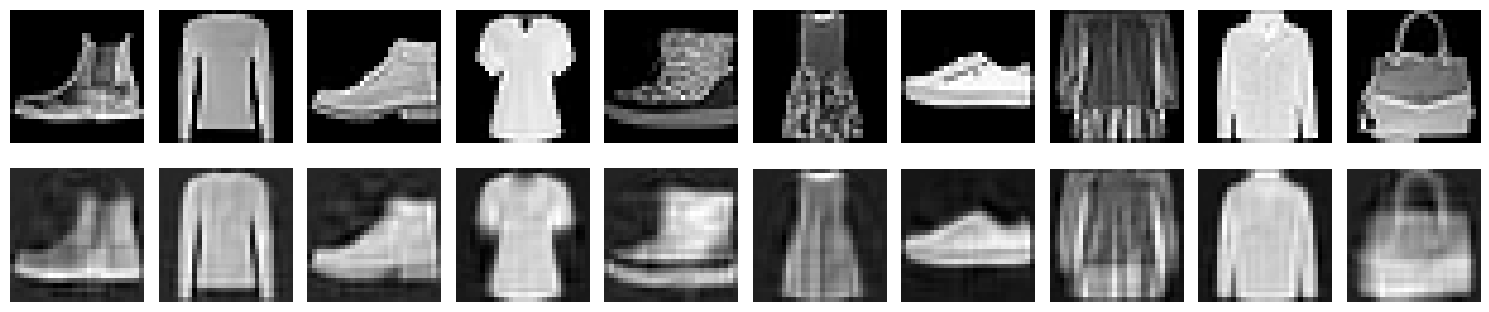

In [35]:

X_reconstruido_std = X_train_pca @ eigenvectors_K.T 
X_reconstruido = X_reconstruido_std * des + med    # des-estandarizar

# 2b - comparación originales vs reconstruidas
utls.plot_images([X_train, X_reconstruido], n_images=10,
            titles=["Original", "Reconstruida PCA"])


#### Entrenamiento de AutoEncoder con PyTorch

In [11]:
from torch.utils.data import DataLoader, TensorDataset


LATENT_DIM = 135  # igual que PCA
EPOCHS = 50
LR = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Datos como tensores
X_train_t = torch.FloatTensor(X_train_std).to(device)  
X_val_t   = torch.FloatTensor(X_test_std).to(device)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)

model = ae.Autoencoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_loss = []
    for (x_batch,) in train_loader:
        optimizer.zero_grad()
        x_hat = model(x_batch)
        loss = criterion(x_hat, x_batch)
        loss.backward()
        optimizer.step()
        batch_loss.append(loss.item())
    
    # Validación
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), X_val_t).item()
    
    train_losses.append(sum(batch_loss) / len(batch_loss))
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    X_train_ae = model.encoder(torch.FloatTensor(X_train_std).to(device)).cpu().numpy()
    X_test_ae  = model.encoder(torch.FloatTensor(X_test_std).to(device)).cpu().numpy()

Epoch 10/50 | Train: 0.1658 | Val: 0.1758
Epoch 20/50 | Train: 0.1276 | Val: 0.1477
Epoch 30/50 | Train: 0.1102 | Val: 0.1251
Epoch 40/50 | Train: 0.1106 | Val: 0.1188
Epoch 50/50 | Train: 0.0921 | Val: 0.1195


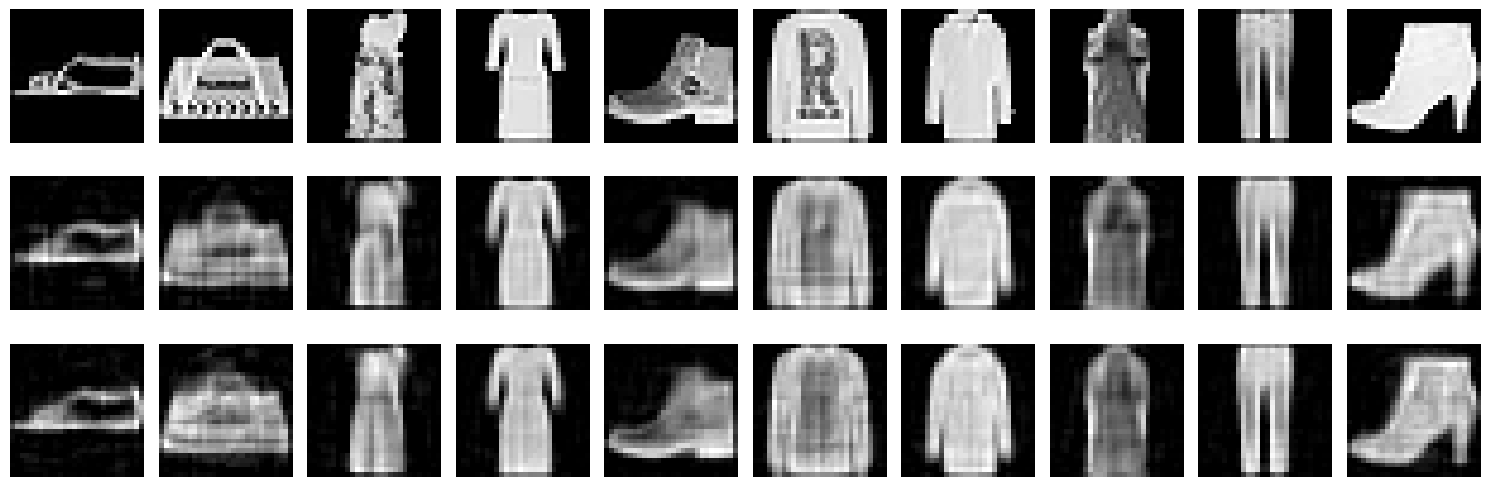

In [12]:
idx = np.random.choice(len(X_test), 10, replace=False)

originales_vis = X_test[idx].astype(np.float32)

# Reconstrucción AE: pasar X_test_std por el modelo completo
model.eval()
with torch.no_grad():
    recon_ae_std = model(torch.FloatTensor(X_test_std[idx]).to(device)).cpu().numpy()
recon_ae = np.clip(recon_ae_std * des + med, 0, 255)

# Reconstrucción PCA
X_test_reconstruido_std = X_test_pca @ eigenvectors_K.T
recon_pca = np.clip(X_test_reconstruido_std[idx] * des + med, 0, 255)

utls.plot_images([originales_vis, recon_pca, recon_ae], n_images=10,
                 titles=["Original", "Reconstruida PCA", "Reconstruida AE"])

In [13]:
print("=== Resumen de representaciones de menor dimensionalidad ===")
print(f"Espacio original   : X_train shape = {X_train_std.shape}")
print(f"Espacio PCA        : X_train_pca shape = {X_train_pca.shape}  | X_test_pca shape = {X_test_pca.shape}")
print(f"Espacio AE         : X_train_ae  shape = {X_train_ae.shape}   | X_test_ae  shape = {X_test_ae.shape}")
print(f"Reducción de dimensionalidad: {X_train_std.shape[1]} → {X_train_pca.shape[1]} (PCA) y {X_train_ae.shape[1]} (AE)")


=== Resumen de representaciones de menor dimensionalidad ===
Espacio original   : X_train shape = (20000, 784)
Espacio PCA        : X_train_pca shape = (20000, 135)  | X_test_pca shape = (5000, 135)
Espacio AE         : X_train_ae  shape = (20000, 135)   | X_test_ae  shape = (5000, 135)
Reducción de dimensionalidad: 784 → 135 (PCA) y 135 (AE)


## 3. Clustering

Algoritmo K-Means

In [ ]:
_, X_cluster, _, y_cluster = utls.stratified_split(X_train_pca, y_train, test_size=3000/len(X_train_pca))

resultados_kmeans = {}
for K in range(5, 16):
    labels, centroids, inertia = clust.kmeans(X_cluster, K=K)
    resultados_kmeans[K] = {"labels": labels, "centroids": centroids, "inertia": inertia}
    print(f"K={K} | Inertia: {inertia:.2f}")

K=5 | Inertia: 1301606.96
K=6 | Inertia: 1230016.29
K=7 | Inertia: 1157933.05
K=8 | Inertia: 1118684.23
K=9 | Inertia: 1083482.96
K=10 | Inertia: 1052177.39
K=11 | Inertia: 1022854.64
K=12 | Inertia: 1000733.62
K=13 | Inertia: 980963.97
K=14 | Inertia: 961478.28
K=15 | Inertia: 945800.96


Algortimo GMM

In [39]:
resultados_gmm = {}
for K in range(5, 16):
    labels, mu, sigma, pi, ll = clust.gmm(X_cluster, K=K)
    resultados_gmm[K] = {"labels": labels, "mu": mu, "ll": ll}
    print(f"K={K} | Log-likelihood: {ll:.2f}")

K=5 | Log-likelihood: -612142.04
K=6 | Log-likelihood: -607022.45
K=7 | Log-likelihood: -604703.28
K=8 | Log-likelihood: -602353.51
K=9 | Log-likelihood: -600006.34
K=10 | Log-likelihood: -597701.98
K=11 | Log-likelihood: -595623.72
K=12 | Log-likelihood: -593815.09
K=13 | Log-likelihood: -594379.30
K=14 | Log-likelihood: -590894.34
K=15 | Log-likelihood: -590777.04


### Analisis de K 

K= 5 | Silhouette K-Means: 0.1489 | Silhouette GMM: 0.0415
K= 6 | Silhouette K-Means: 0.1616 | Silhouette GMM: 0.0396
K= 7 | Silhouette K-Means: 0.1628 | Silhouette GMM: 0.0523
K= 8 | Silhouette K-Means: 0.1534 | Silhouette GMM: 0.0680
K= 9 | Silhouette K-Means: 0.1653 | Silhouette GMM: 0.0603
K=10 | Silhouette K-Means: 0.1481 | Silhouette GMM: 0.0328
K=11 | Silhouette K-Means: 0.1447 | Silhouette GMM: 0.0242
K=12 | Silhouette K-Means: 0.1460 | Silhouette GMM: 0.0179
K=13 | Silhouette K-Means: 0.1402 | Silhouette GMM: 0.0300
K=14 | Silhouette K-Means: 0.1409 | Silhouette GMM: 0.0144
K=15 | Silhouette K-Means: 0.1266 | Silhouette GMM: 0.0404


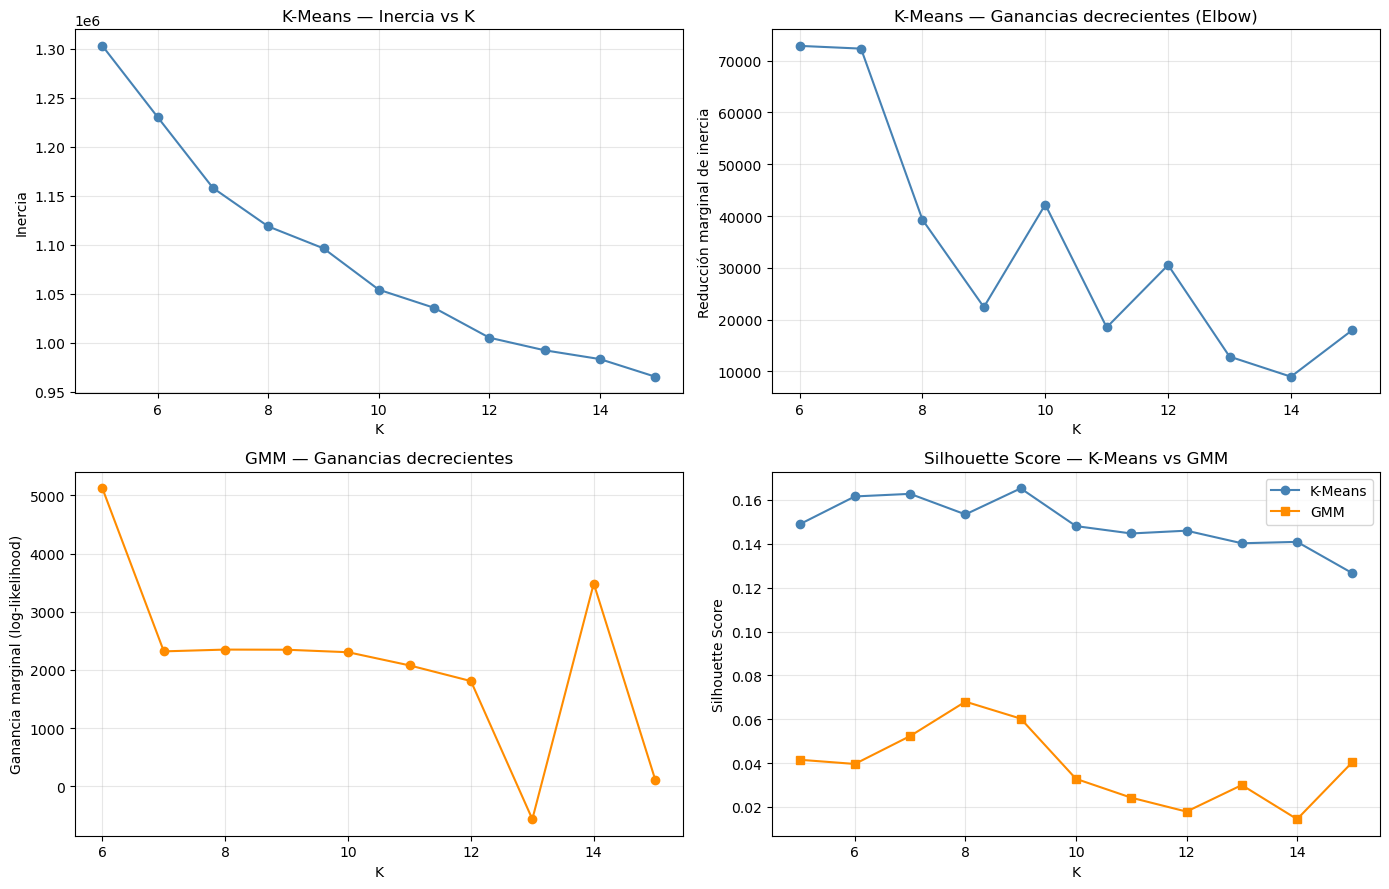

In [41]:
# ── K-Means: Elbow (inercia) ────────────────────────────────────────────────
ks = list(resultados_kmeans.keys())
inercias = [resultados_kmeans[k]["inertia"] for k in ks]
ganancia_marginal_kmeans = [inercias[i-1] - inercias[i] for i in range(1, len(inercias))]  # reducción

# ── GMM: Ganancias decrecientes (log-likelihood) ─────────────────────────────
ks_gmm = list(resultados_gmm.keys())
lls = [resultados_gmm[k]["ll"] for k in ks_gmm]
ganancia_marginal_gmm = [lls[i] - lls[i-1] for i in range(1, len(lls))]

# ── Silhouette: K-Means y GMM ────────────────────────────────────────────────
silhouette_kmeans = {}
silhouette_gmm    = {}
for K in range(5, 16):
    silhouette_kmeans[K] = clust.silhouette_score(X_cluster, resultados_kmeans[K]["labels"])
    silhouette_gmm[K]    = clust.silhouette_score(X_cluster, resultados_gmm[K]["labels"])
    print(f"K={K:2d} | Silhouette K-Means: {silhouette_kmeans[K]:.4f} | Silhouette GMM: {silhouette_gmm[K]:.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Elbow K-Means
axes[0, 0].plot(ks, inercias, marker='o', color='steelblue')
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inercia")
axes[0, 0].set_title("K-Means — Inercia vs K")
axes[0, 0].grid(alpha=0.3)

# 2) Ganancia marginal K-Means
axes[0, 1].plot(ks[1:], ganancia_marginal_kmeans, marker='o', color='steelblue')
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Reducción marginal de inercia")
axes[0, 1].set_title("K-Means — Ganancias decrecientes (Elbow)")
axes[0, 1].grid(alpha=0.3)

# 3) Ganancia marginal GMM
axes[1, 0].plot(ks_gmm[1:], ganancia_marginal_gmm, marker='o', color='darkorange')
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("Ganancia marginal (log-likelihood)")
axes[1, 0].set_title("GMM — Ganancias decrecientes")
axes[1, 0].grid(alpha=0.3)

# 4) Silhouette K-Means vs GMM
axes[1, 1].plot(list(silhouette_kmeans.keys()), list(silhouette_kmeans.values()),
                marker='o', label='K-Means', color='steelblue')
axes[1, 1].plot(list(silhouette_gmm.keys()), list(silhouette_gmm.values()),
                marker='s', label='GMM', color='darkorange')
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("Silhouette Score")
axes[1, 1].set_title("Silhouette Score — K-Means vs GMM")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3b. Visualización t-SNE de los Clusters

Se toma el mejor K del análisis anterior (K=5, mayor Silhouette Score en GMM) y se aplica la implementación propia de t-SNE sobre el espacio latente del PCA (135 dimensiones → 2D). Luego se grafican las muestras coloreadas por cluster asignado y por clase real para evaluar la calidad del clustering.

In [48]:
import tsne as tsne_mod

# Mejor K del análisis anterior: K=5 (mayor Silhouette Score en GMM)
BEST_K = 8
labels_best = resultados_kmeans[BEST_K]["labels"]

# t-SNE sobre el espacio latente del PCA (135 dims → 2D)
# X_cluster: submuestra de 3000 puntos ya en espacio PCA
Y_tsne = tsne_mod.tsne(
    X_cluster,
    n_components=2,
    perplexity=30,
    n_iter=500,
    lr=200.0,
    early_exaggeration=4.0,
    exaggeration_iter=100,
    random_seed=42,
    verbose=True
)
print("t-SNE listo. Shape:", Y_tsne.shape)

[t-SNE] n=3000, d=135, perplexity=30, n_iter=500, lr=200.0
[t-SNE] Calculando probabilidades en alta dimensión...
[t-SNE] Iniciando optimización...
[t-SNE] Iter  100/500 | KL divergence: 2.6973
[t-SNE] Iter  200/500 | KL divergence: 1.7391
[t-SNE] Iter  300/500 | KL divergence: 1.5500
[t-SNE] Iter  400/500 | KL divergence: 1.4532
[t-SNE] Iter  500/500 | KL divergence: 1.3909
[t-SNE] Listo.
t-SNE listo. Shape: (3000, 2)


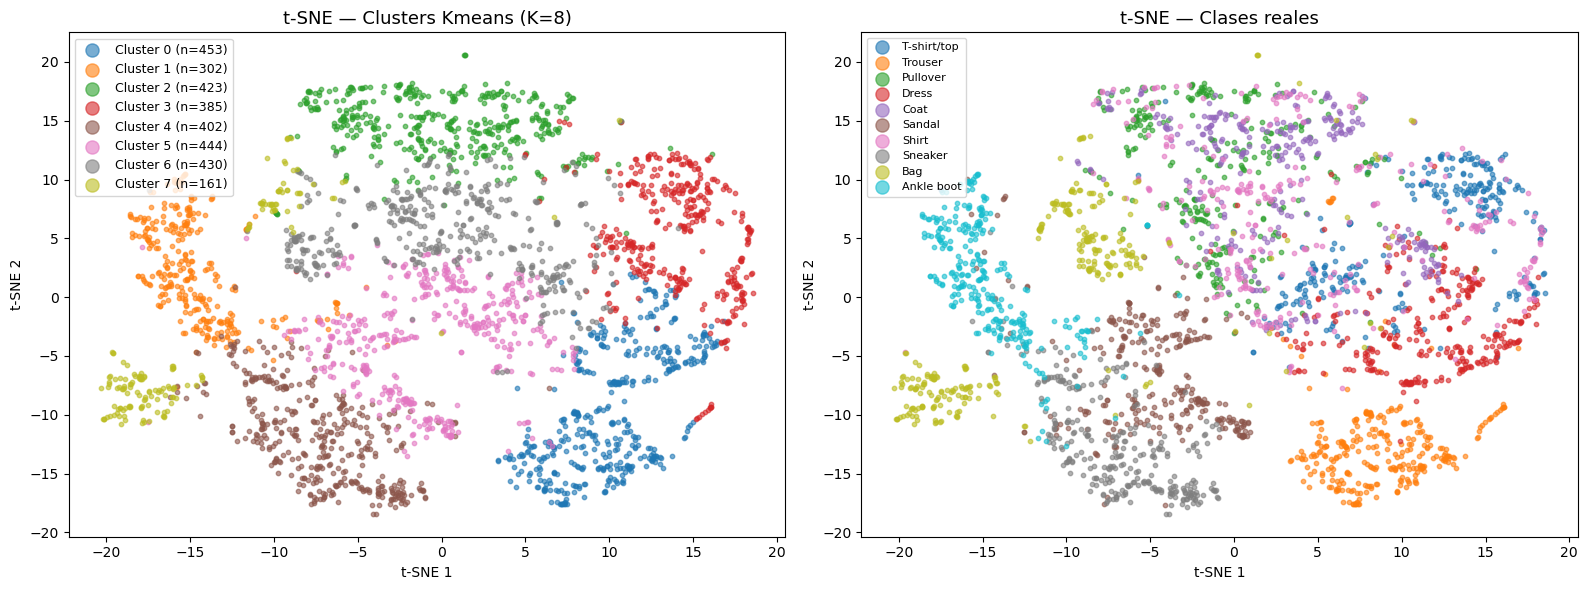

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap_clusters = plt.cm.tab10
cmap_classes  = plt.cm.tab10

# --- Izquierdo: color por cluster asignado ---
ax = axes[0]
for k in range(BEST_K):
    mask = labels_best == k
    ax.scatter(Y_tsne[mask, 0], Y_tsne[mask, 1],
               c=[cmap_clusters(k / BEST_K)],
               label=f"Cluster {k} (n={mask.sum()})",
               s=10, alpha=0.6)
ax.set_title(f"t-SNE — Clusters Kmeans (K={BEST_K})", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3, fontsize=9)

# --- Derecho: color por clase real ---
ax = axes[1]
n_classes = len(class_names)
for c in sorted(class_names.keys()):
    mask = y_cluster == c
    ax.scatter(Y_tsne[mask, 0], Y_tsne[mask, 1],
               c=[cmap_classes(c / n_classes)],
               label=class_names[c],
               s=10, alpha=0.6)
ax.set_title("t-SNE — Clases reales", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=3, fontsize=8, loc="best")

plt.tight_layout()
plt.show()

In [45]:
# Tabla de distribución de clases reales por cluster
rows = []
for k in range(BEST_K):
    mask = labels_best == k
    row = {"Cluster": k, "N muestras": int(mask.sum())}
    for c in sorted(class_names.keys()):
        row[class_names[c]] = int((y_cluster[mask] == c).sum())
    rows.append(row)

df_dist = pd.DataFrame(rows).set_index("Cluster")
print("Distribución de clases reales por cluster:")
print(df_dist.to_string())

# Homogeneidad: clase dominante y su proporción dentro del cluster
print("\nClase dominante y homogeneidad por cluster:")
for k in range(BEST_K):
    mask = labels_best == k
    counts_k = np.array([(y_cluster[mask] == c).sum() for c in sorted(class_names.keys())])
    dom_idx   = np.argmax(counts_k)
    dom_class = class_names[dom_idx]
    homog     = counts_k[dom_idx] / mask.sum()
    print(f"  Cluster {k}: N={mask.sum():4d} | Clase dominante: {dom_class:15s} ({homog:.1%})")

Distribución de clases reales por cluster:
         N muestras  T-shirt/top  Trouser  Pullover  Dress  Coat  Sandal  Shirt  Sneaker  Bag  Ankle boot
Cluster                                                                                                  
0               261           30       34         3    148    21       0     25        0    0           0
1               263            0        0         0      0     0      44      0       35    1         183
2               331            0      251         0     78     0       0      2        0    0           0
3               338            0        0       100      4   173       0     59        0    2           0
4               510          130        5       109     14    49      13     86        4   99           1
5               449           23        6        25     11    10      79     23        6  166         100
6                41            5        0         2      0     0       3      5        0   22           4
7  

## Análisis de calidad de clusters (K-Means, K=8)

La visualización t-SNE con K-Means (K=8) muestra una segmentación coherente con
la estructura real del dataset. Los clusters presentan tamaños relativamente
balanceados (entre n=161 y n=453), sin subpoblaciones degeneradas.

Comparando ambos plots, se observa que los clusters que mejor se alinean con
clases reales son los correspondientes a **Trouser** (región inferior izquierda,
compacta y bien separada), **Ankle boot** y **Sneaker** (regiones derechas,
con buena cohesión interna). Estas clases tienen morfología visual distintiva
y ocupan regiones del espacio latente sin superposición significativa con otras.

Por el contrario, la zona central-superior del embedding agrupa prendas superiores
(T-shirt, Pullover, Coat, Shirt, Dress) en clusters con mayor mezcla de clases,
lo que refleja su proximidad intrínseca en el espacio de features. K-Means, al
asumir clusters esféricos, divide esta región en fronteras geométricas que no
necesariamente respetan las fronteras semánticas reales.

K=8 fue seleccionado como el valor óptimo por maximizar el Silhouette score entre
los valores evaluados en el rango [5, 15], lo que indica la mejor relación entre
cohesión intra-cluster y separación inter-cluster sin requerir etiquetas.
En consecuencia, el modelo recupera satisfactoriamente las clases visualmente
separables del dataset, mientras que la confusión residual en la zona central
refleja una limitación del espacio latente más que del algoritmo de clustering.